# Dataset 2 Analysis 

This notebook explores a second dataset to compare data quality and patterns with the first dataset.

In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/gym_dataset.csv")

print("Shape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

display(df.head())

Shape of dataset:
(973, 15)

Columns:
Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## Dataset Overview

This dataset contains information about gym members, including their physical attributes, workout behavior, and fitness metrics.

The goal is to analyze relationships between variables such as workout duration, heart rate, and calories burned.

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [9]:
print("\nMissing values:")
print(df.isna().sum())


Missing values:
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64


## Data Quality Check

The dataset is checked for:
- Data types
- Missing values

This step ensures the data is clean and ready for analysis.

In [11]:
selected_cols = [
    "Session_Duration (hours)",
    "Avg_BPM",
    "Calories_Burned"
]

df_selected = df[selected_cols].dropna()

display(df_selected.head())

,Session_Duration (hours),Avg_BPM,Calories_Burned
0,1.69,157,1313.0
1,1.30,151,883.0
2,1.11,122,677.0
3,0.59,164,532.0
4,0.64,158,556.0


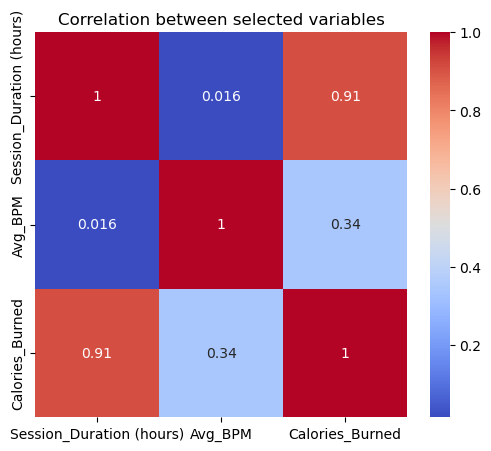

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_selected.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation between selected variables")
plt.show()

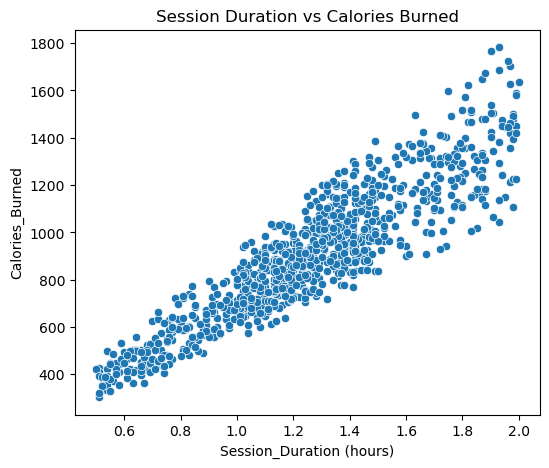

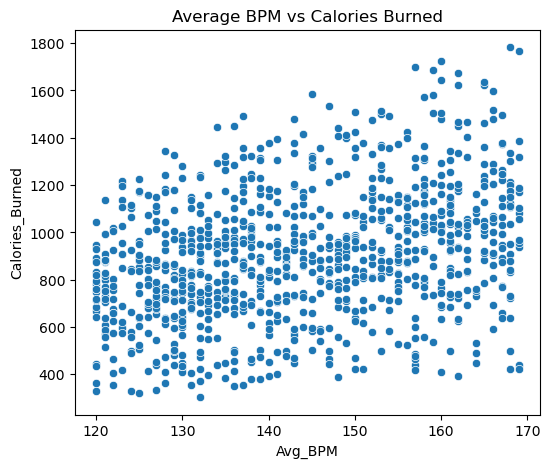

In [13]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_selected, x="Session_Duration (hours)", y="Calories_Burned")
plt.title("Session Duration vs Calories Burned")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_selected, x="Avg_BPM", y="Calories_Burned")
plt.title("Average BPM vs Calories Burned")
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_selected)

scaled_df = pd.DataFrame(scaled_data, columns=df_selected.columns)

display(scaled_df.head())

,Session_Duration (hours),Avg_BPM,Calories_Burned
0,1.264598,0.922970,1.495690
1,0.127098,0.504494,-0.082284
2,-0.427068,-1.518142,-0.838243
3,-1.943735,1.411193,-1.370351
4,-1.797902,0.992716,-1.282278


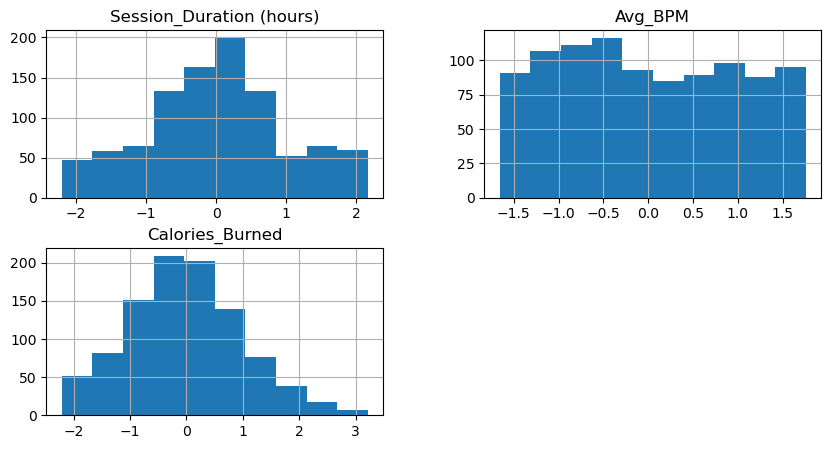

In [15]:
scaled_df.hist(figsize=(10,5))
plt.show()

## Data Standardization

The data is standardized to have mean = 0 and standard deviation = 1.

This is important before applying PCA, since PCA is sensitive to scale.

## Distribution after Scaling

The histograms show that the variables are now centered around zero and have similar spread.